In [2]:
import os
import pickle
import glob
import skimage
import skimage.transform
import numpy as np
from tqdm.notebook import tqdm
from os import listdir
from os.path import isfile, join
import shutil, os
from scipy.signal import find_peaks
import csv

from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import matplotlib.colors as colors
import matplotlib.cm as cm

import sys
sys.path.append('../../functions')

import chirp_functions as proc
import stmpy

In [3]:
def return_sublat(origin, coord_crt, lat_vecs, sub_lat_vecs, atol=1e-3):
    """
    Given a coordinate in Cartesian space, return which sublattice triangle it belongs to.

    inputs:
    - origin: the origin of the lattice (Cartesian coordinates)
    - coord_crt: the coordinate to check (Cartesian coordinates)
    - lat_vecs: the lattice vectors (2D array). I'm assuming a 2D lattice with two basis vectors.
    - sub_lat_vecs: the sublattice vectors (2D array). Each vector represents the position of a sublattice point within the unit cell.

    returns:
    - sublattice index (0, 1, or 2) of the coordinate
    """


    # Shift the coordinate to the origin
    rel_coord = np.array(coord_crt) - np.array(origin)

    # Find the integer multiples of the lattice vectors
    n2 = (rel_coord[0] * lat_vecs[0][1] - rel_coord[1] * lat_vecs[0][0]) / (lat_vecs[1][0] * lat_vecs[0][1] - lat_vecs[1][1] * lat_vecs[0][0])
    n1 = (rel_coord[0] * lat_vecs[1][1] - rel_coord[1] * lat_vecs[1][0]) / (lat_vecs[0][0] * lat_vecs[1][1] - lat_vecs[0][1] * lat_vecs[1][0])

    # Round n1 and n2 to the nearest integer if they are within atol, otherwise take the floor. This is for dealing with the floating point precision issue.
    if np.abs(n1 - round(n1)) < atol:
        n1 = int(round(n1))
    else:
        n1 = np.floor(n1)

    if np.abs(n2 - round(n2)) < atol:
        n2 = int(round(n2))
    else:
        n2 = np.floor(n2)

    # Calculate the fractional coordinate within the unit cell
    frac = rel_coord - n1 * lat_vecs[0] - n2 * lat_vecs[1]

    # Determine which sublattice point the fractional coordinate is closest to
    for i in range(len(sub_lat_vecs)):
        if np.allclose(frac, sub_lat_vecs[i], atol=atol):
            return i

    # If no match is found, return -1 
    return -1

def mirror_point(pt_coord, line_slope):
    x0 = pt_coord[0]
    y0 = pt_coord[1]

    # first find the angle between the point and the line
    angle = np.arctan2(line_slope, 1) - np.arctan2(y0, x0)

    # then find the mirrored point by rotating (x0, y0) by 2 times the angle
    x1 = x0 * np.cos(2*angle) - y0 * np.sin(2*angle)
    y1 = x0 * np.sin(2*angle) + y0 * np.cos(2*angle)

    return x1, y1

def rotate_point(pt_coord, angle):
    x0 = pt_coord[0]
    y0 = pt_coord[1]

    x1 = x0 * np.cos(angle) - y0 * np.sin(angle)
    y1 = x0 * np.sin(angle) + y0 * np.cos(angle)

    return x1, y1


In [4]:
x_unit = 10 * np.sqrt(3)/4
y_unit = 10 * 3/4
lat_vecs = np.array([[4*x_unit, 0], [-2*x_unit, 2*y_unit]])
sub_lat_vecs = np.array([[-x_unit, y_unit], [0, 0], [x_unit, y_unit]])
coeffs = [5,149]
coords = coeffs[0] * np.array(lat_vecs[0]) + coeffs[1] * np.array(lat_vecs[1]) + sub_lat_vecs[2]
a = return_sublat([0,0], coords, lat_vecs, sub_lat_vecs)
print(a)

2


# Preprocessing

In [5]:
# define directories
raw_dir = '../../../data/kagome-02.26.2022-center/raw/band_structure/'
processed_dir = '../../../data/kagome-02.26.2022-center/preprocessed_band/'

# extract the sweep frequencies from one of the raw pkl files
files = glob.glob(os.path.join(raw_dir, '*.pkl'))

data = pickle.load(open(files[0], 'rb'))
freq_list = data[:,0]

In [6]:
proc.preprocess_chirp(data_dir = raw_dir, 
                       frequencies = freq_list, 
                       targetfile = processed_dir, 
                       title = 'scppos_', setno = 0)

Found 185 records
Preprocessing complete!


# Sweep visualization

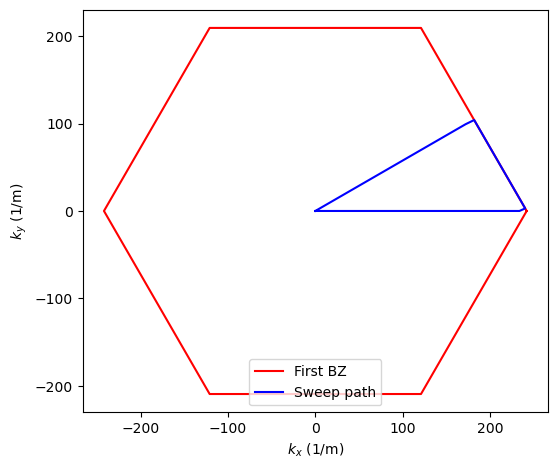

In [7]:
# visualizing the 3 sweeps in reciprocal space


freqs = np.array([(0, freq_list)], dtype=object)

# Lattice parameters
L = 0.01 # Length of the hexagon side in real space (m)
kxmax = 4*np.pi/(3*np.sqrt(3) * L) # Max kx value in the first Brillouin zone
kymax = 2*np.pi/(3*L) # Max ky value in the first Brillouin zone

# Define the GKMG sweep path in reciprocal space
b_res = 50
b = np.linspace(0, 1.5+np.sqrt(3)/2, b_res) 
kxb = np.zeros(len(b))
kyb = np.zeros(len(b))

for i in range(len(b)):
    if b[i] < 1:   
        kxb[i] = 4 * np.pi / (3 * np.sqrt(3) * L) * b[i]
        kyb[i] = 0   
    elif b[i] < 1.5: 
        kxb[i] = 4 * np.pi / (3 * np.sqrt(3) * L) - 2 * np.pi / (3 * np.sqrt(3) * L) * (b[i]-1)
        kyb[i] = 2 * np.pi / (3 * L) * (b[i]-1)
    else:
        kxb[i] = (1- (b[i] - 1.5) * 2 / np.sqrt(3)) * np.pi / (np.sqrt(3) * L)
        kyb[i] = (1- 2 / (np.sqrt(3)) * (b[i]-1.5)) * np.pi / (3 * L)
        
        
# Visualize the Brillouin zone and the sweep path
xBZ = [kxmax, 0.5*kxmax, -0.5*kxmax, -kxmax, -0.5*kxmax, 0.5*kxmax, kxmax]
yBZ = [0, kymax, kymax, 0, -kymax, -kymax, 0]


plt.figure(figsize=(6,6))
plt.plot(xBZ, yBZ, 'r-', label='First BZ')
plt.plot(kxb, kyb, 'b-', label='Sweep path')
plt.xlabel(r'$k_x$ (1/m)')
plt.ylabel(r'$k_y$ (1/m)')
plt.legend(loc='lower center')
plt.gca().set_aspect('equal')

In [8]:
# Load preprocessed data



In [9]:


lat_vecs = np.array([[4, 0], [2, 2]])
sub_lat_vecs = np.array([[0, 0], [1, 1], [3, 1]])

x_unit = 10 * np.sqrt(3)/4/1000
y_unit = 10 * 3/4/1000

reciprocal_data = np.zeros((len(freq_list), b_res, len(sub_lat_vecs)))

rot_angles = np.linspace(0, 360, 6, endpoint=False) * np.pi / 180

for setno, values in freqs:
    for i in tqdm(range(len(values))):
        
        with open(processed_dir + '_' + str(values[i]) + '_' + str(setno) + '.pkl','rb') as f:
            real_data = pickle.load(f) 
            # Clear sublattice lists for each iteration
            sublat_data = [[] for _ in range(len(sub_lat_vecs))]

            # Sort the real data into the 3 sublattices
            for point in real_data:
                sub_lat = return_sublat([0,0], np.array([point[0], point[1]]), lat_vecs, sub_lat_vecs)

                for sublat_num in range(len(sub_lat_vecs)):
                    if sub_lat == sublat_num:
                        sublat_data[sublat_num].append(point)
    
            for j in range(b_res):
                kx = kxb[j]
                ky = kyb[j]

                # mirror the point (kx, ky) about the line y=1/sqrt(3)*x to get kx_mirr and ky_mirr
                kx_mirr, ky_mirr = mirror_point((kx, ky), 1/np.sqrt(3))

                for k in range(len(sub_lat_vecs)):
                    for l in range(len(rot_angles)):
                        kx_crt, ky_crt = rotate_point((kx, ky), rot_angles[l])
                        kx_mirr_crt, ky_mirr_crt = rotate_point((kx_mirr, ky_mirr), rot_angles[l])

                        reciprocal_data[i][j][k] += np.abs(np.array([point[2] * np.exp(-1j * (kx_crt * (point[0]*x_unit) + ky_crt * (point[1]*y_unit) + (point[3] / 57.2957795131))) 
                                        for point in sublat_data[k]]).sum())
                        reciprocal_data[i][j][k] += np.abs(np.array([point[2] * np.exp(-1j * (kx_mirr_crt * (point[0]*x_unit) + ky_mirr_crt * (point[1]*y_unit) + (point[3] / 57.2957795131))) 
                                        for point in sublat_data[k]]).sum())

reciprocal_data_avg = np.average(reciprocal_data, axis=2)/ (len(rot_angles)*2)

  0%|          | 0/426 [00:00<?, ?it/s]

In [12]:
np.max(reciprocal_data_plot)

np.float64(3.043141587409531)

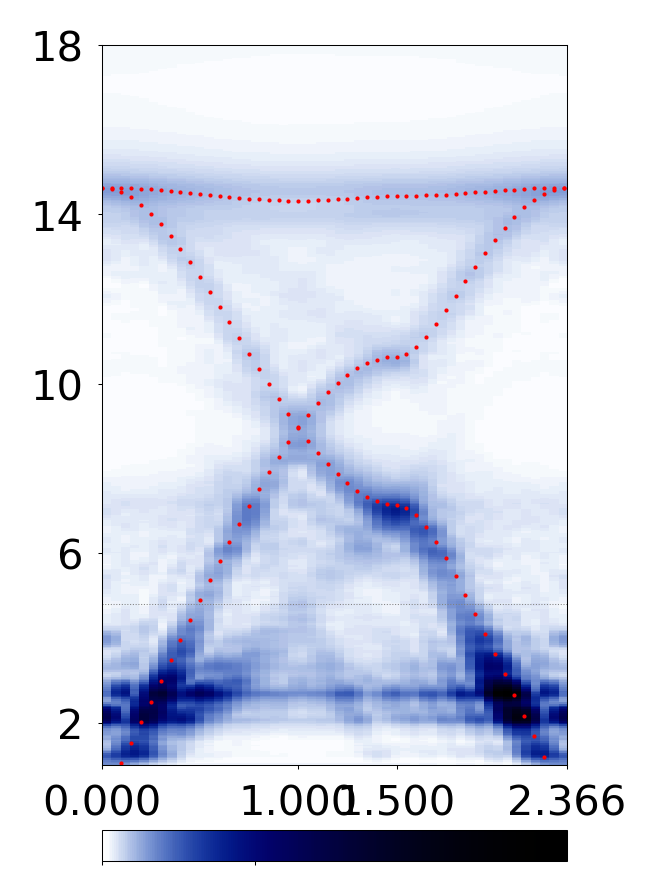

In [20]:
reciprocal_data_plot = reciprocal_data_avg

folder = '../../../data/kagome-02.26.2022-center/'

b_sim = []
band1 = []
band2 = []
band3 = []


with open('../../../data/simulation/kagome_machine_bands_clean.csv', newline='') as csvfile:
    reader = csv.reader(csvfile, delimiter=',')
    next(reader)
    
    for row in reader:
        b_sim.append(float(row[0]))
        band1.append(float(row[1]))
        band2.append(float(row[2]))
        band3.append(float(row[3]))


# GKMG sweep
fig, ax = plt.subplots(figsize = (2, 4), dpi = 300)
freq = np.linspace(1000.0, 18000.0, 426)
min_index = np.where(freq == 1000.0)[0][0]
max_index = len(reciprocal_data)
b_mesh, freq_mesh = np.meshgrid(b, freq / 1000)
plt.imshow(
    reciprocal_data_plot,
    extent=[b[0], b[-1], 1, 18],
    origin='lower',
    aspect='auto',
    interpolation='none',
    cmap=stmpy.cm.blue3_r
)
ax.plot(b_sim, band1, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)
ax.plot(b_sim, band2, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)
ax.plot(b_sim, band3, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)
ax.axis([b[0], b[-1], 1, 18])
#cb = stmpy.image.add_cbar(ax=ax, fs=6.5, length='25%', sf=1, pad=0.07, labelpad=0.03)
cb = plt.colorbar(ticks = [0,1], location='bottom', pad=0.07, aspect=15)
# set the length of the colorbar to be 50% of the axis length
cb.set_ticks([0, 1], labels=['', ''])
cb.ax.tick_params(labelsize=6.5)
cb.ax.xaxis.set_tick_params(width=0.25, length = 1)
cb.outline.set_linewidth(0.25)
ax.set_yticks(np.linspace(2, 18, 5))
ax.set_xticks([0, 1, 1.5, b[-1]])
ax.axhline(4.8, color='gray', linestyle=':', linewidth=0.25)

for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)

#ax.tick_params(labelbottom=False)
#ax.tick_params(labelleft=False)


ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)




reciprocal_data_plot shape: (426, 50)
min/max: 0.020952718208435226 3.043141587409531
reciprocal_data_plot == reciprocal_data_avg (allclose): True
Using row index 95, mapped frequency ~4.800 kHz
gkmg_profile shape: (50,)


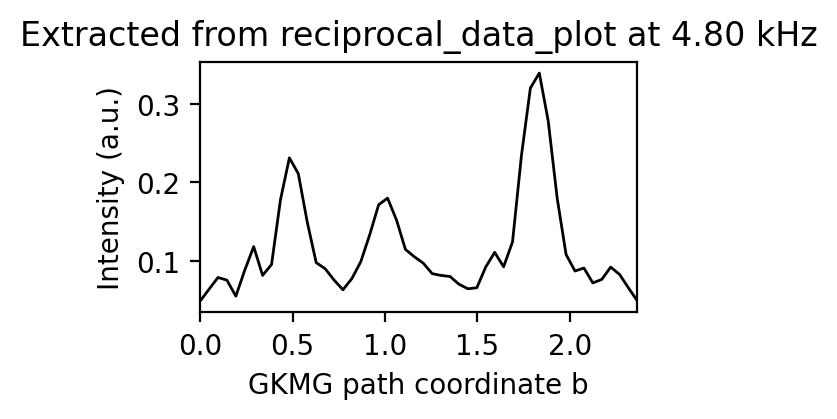

In [22]:
# Verify and extract data directly from reciprocal_data_plot (cell 20 image source)
print('reciprocal_data_plot shape:', reciprocal_data_plot.shape)
print('min/max:', float(np.min(reciprocal_data_plot)), float(np.max(reciprocal_data_plot)))

# Check agreement with the averaged array used to construct it
same_as_avg = np.allclose(reciprocal_data_plot, reciprocal_data_avg)
print('reciprocal_data_plot == reciprocal_data_avg (allclose):', same_as_avg)

# Extract a GKMG profile at a chosen frequency (kHz)
target_freq_khz = 4.8
freq_khz_axis = np.linspace(1.0, 18.0, reciprocal_data_plot.shape[0])
f_idx = int(np.argmin(np.abs(freq_khz_axis - target_freq_khz)))

gkmg_profile = reciprocal_data_plot[f_idx, :]
print(f'Using row index {f_idx}, mapped frequency ~{freq_khz_axis[f_idx]:.3f} kHz')
print('gkmg_profile shape:', gkmg_profile.shape)

# Optional quick plot of extracted row
fig, ax = plt.subplots(figsize=(3.0, 2.2), dpi=200)
ax.plot(b, gkmg_profile, 'k-', lw=1)
ax.set_xlabel('GKMG path coordinate b')
ax.set_ylabel('Intensity (a.u.)')
ax.set_title(f'Extracted from reciprocal_data_plot at {freq_khz_axis[f_idx]:.2f} kHz')
ax.set_xlim(b[0], b[-1])
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Sublattice Coordinates')

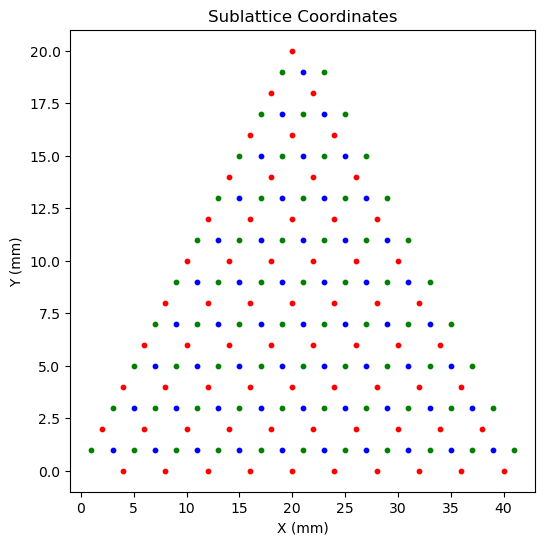

In [55]:
sublat_1_data = np.array(sublat_1_data)
sublat_2_data = np.array(sublat_2_data)
sublat_3_data = np.array(sublat_3_data)

# plot the x and y coordinates of the sublattices
plt.figure(figsize=(6, 6))
plt.scatter(sublat_1_data[:, 0], sublat_1_data[:, 1], c='r', label='Sublattice 1', s=10)
plt.scatter(sublat_2_data[:, 0], sublat_2_data[:, 1], c='g', label='Sublattice 2', s=10)
plt.scatter(sublat_3_data[:, 0], sublat_3_data[:, 1], c='b', label='Sublattice 3', s=10)
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Sublattice Coordinates')